<a href="https://colab.research.google.com/github/metio21/Midterm/blob/master/Modeling_Midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of rows: 62
Column names: ['Close', 'High', 'Low', 'Open', 'Volume']
Data for April 10th:
                  Close        High         Low        Open    Volume
Date                                                                
2025-04-10  181.220001  186.869995  175.850006  185.440002  68302000
Lowest stock value on April 10th: 175.85000610351562


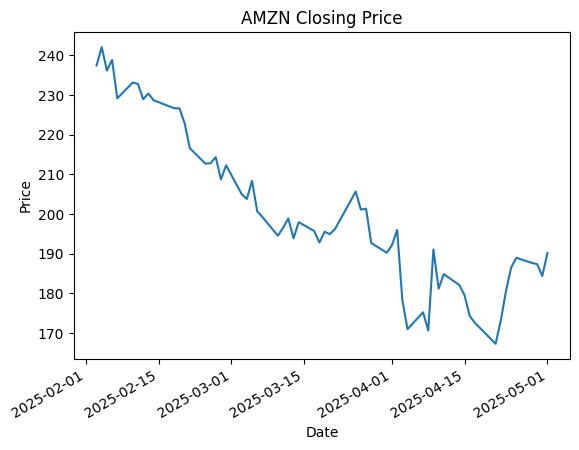

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

ticker = "AMZN"
url = f"https://raw.githubusercontent.com/itb-ie/midterm_data/refs/heads/main/{ticker}.csv"
with open("company.csv", "w") as f:
    f.write(requests.get(url).text)

df = pd.read_csv("company.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

print("Number of rows:", len(df))

print("Column names:", df.columns.tolist())


# finds row(s) for April 10th and print the lowest value that day
april_10_data = df[df.index.strftime('%m-%d') == '04-10']
print("Data for April 10th:\n", april_10_data)

#finds lowest stock value on April 10th across all columns
if not april_10_data.empty:
    lowest_value = april_10_data.min().min()
    print("Lowest stock value on April 10th:", lowest_value)
else:
    print("No data for April 10th.")

#plots close column
df["Close"].plot(title=f"{ticker} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


In [5]:
import numpy as np

a = np.arange(0, 12)
print(a)

a[0] = 2
a[1] = 2
a[2] = 4
a[3] = 8
a[4] = 14
a[5] = 22
a[6] = 32
a[7] = 44
a[8] = 58
a[9] = 74
a[10] = 92
a[11] = 112

a = a.reshape(2, 6)
print(a)


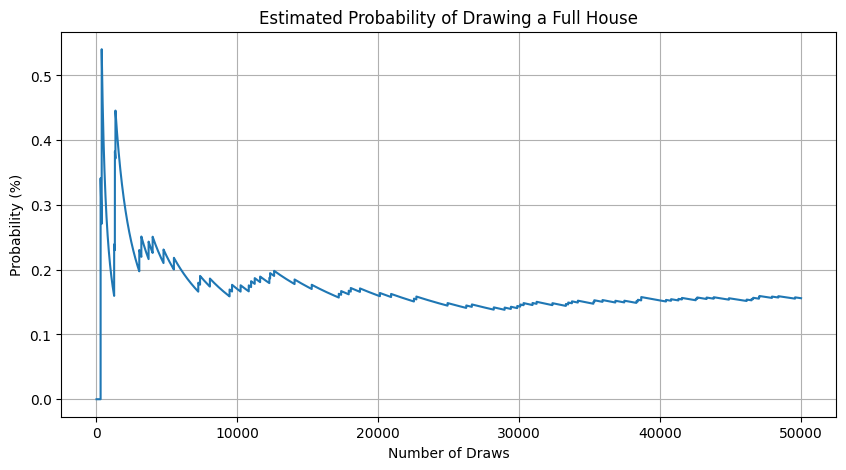


Final estimated probability of drawing a Full House: 0.1560%


In [8]:
# --- Card and Deck Classes ---

import random
import matplotlib.pyplot as plt

class Card:
    RANKS = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
    SUITS = ["♣", "♦", "♥", "♠"]

    def __init__(self, suit, rank):
        if rank not in self.RANKS:
            raise ValueError("Invalid rank")
        if suit not in self.SUITS:
            raise ValueError("Invalid suit")
        self._suit = suit
        self._rank = rank

    def __eq__(self, other):
        return self.rank == other.rank

    def __gt__(self, other):
        return self.RANKS.index(self.rank) > self.RANKS.index(other.rank)

    def __str__(self):
        return f"{self._rank}{self._suit}"

    def __repr__(self):
        return self.__str__()

    @property
    def suit(self):
        return self._suit

    @property
    def rank(self):
        return self._rank

class Deck:
    def __init__(self):
        self._deck = [Card(suit, rank) for suit in Card.SUITS for rank in Card.RANKS]

    def __str__(self):
        return str(self._deck)

    def shuffle(self):
        random.shuffle(self._deck)

    def deal(self):
        return self._deck.pop(0)

# --- PokerHand Class ---

class PokerHand:
    def __init__(self, deck):
        self._cards = [deck.deal() for _ in range(5)]

    @property
    def cards(self):
        return self._cards

    def __str__(self):
        return str(self.cards)

    @property
    def number_matches(self):
        matches = 0
        for i in range(len(self.cards)):
            for j in range(len(self.cards)):
                if i != j and self.cards[i].rank == self.cards[j].rank:
                    matches += 1
        return matches

    @property
    def is_full_house(self):
        return self.number_matches == 8  # 3 of a kind + 2 of a kind

# --- FORM FIELD SLIDER --- #
iterations = 50000 # @param {type:"slider", min:1000, max:50000, step:100}

# --- Simulation Function ---

def simulate_full_house(iterations):
    full_house_count = 0
    x_vals = []
    y_vals = []

    for i in range(1, iterations + 1):
        deck = Deck()
        deck.shuffle()
        hand = PokerHand(deck)
        if hand.is_full_house:
            full_house_count += 1
        probability = (full_house_count / i) * 100
        x_vals.append(i)
        y_vals.append(probability)

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(x_vals, y_vals)
    plt.xlabel("Number of Draws")
    plt.ylabel("Probability (%)")
    plt.title("Estimated Probability of Drawing a Full House")
    plt.grid(True)
    plt.show()

    print(f"\nFinal estimated probability of drawing a Full House: {y_vals[-1]:.4f}%")

# --- Run the Simulation ---
simulate_full_house(iterations)



In [ ]:
import numpy as np
import pandas as pd

# Create the DataFrame
df = pd.DataFrame(np.random.randn(4, 4), index=[1, 2, 3, 4], columns=['a', 'b', 'c', 'd'])

# Display the full DataFrame
print("Full DataFrame:")
print(df)

print("\nValue at column 'c' and row 4 (labelled):")

print("Method 1 (indexing):", df['c'][4])

print("Method 2 (.loc):", df.loc[4, 'c'])

print("Method 3 (.iloc):", df.iloc[3, 2])
#works as an index so print 4 row thrid column

#trying to get C4 every times